# 📊 Adım 7 — İstatistiksel Analiz

Modellerimiz arasında istatistiksel anlamlı fark var mı?

**Neden gerekli?**  
Tek bir test setinde ET'nin RF'den daha iyi görünmesi şans eseri olabilir.  
20 split üzerinden **istatistiksel testler** bunu netleştirir.

> **Finansal analoji:** Bir fon yöneticisi 3 yıl boyunca piyasayı yendi.  
> Ama bu alpha mı, yoksa şans mı? Sharpe ratio ve t-testi bunu ayırt eder.  
> Biz de aynısını yapıyoruz: Wilcoxon + Friedman = ML'nin Sharpe ratio testi.

**Testler:**
- **Friedman Testi:** 3 model arasında genel fark var mı?  
- **Wilcoxon Signed-Rank:** İkili karşılaştırmalar (RF vs ET, RF vs GB, ET vs GB)  
- **Bonferroni Düzeltmesi:** 3 karşılaştırma yaptığımız için p-değerini sıkılaştırıyoruz  

---

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setup — önceki notebook'lardan
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import VarianceThreshold
from mrmr import mrmr_classif
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('Kütüphaneler hazır ✓')


Kütüphaneler hazır ✓


In [2]:
normal = pd.read_csv('../data/normal_radiomics.csv')
papil  = pd.read_csv('../data/papilodem_radiomics.csv')
normal['label'] = 0; papil['label'] = 1
papil['PatientIndex'] = papil['PatientIndex'] + 1000  # Normal ve papilödem ID'leri örtüşüyor, offset ekle
df = pd.concat([normal, papil], ignore_index=True)
feature_cols = [c for c in df.columns if c.startswith('Feature_')]

def hasta_bazinda_bol(df, test_ratio=0.20, val_ratio=0.10, random_state=42):
    rng = np.random.RandomState(random_state)
    hasta_etiket = df.groupby('PatientIndex')['label'].first()
    train_idx, val_idx, test_idx = [], [], []
    for sinif in [0, 1]:
        hastalar = hasta_etiket[hasta_etiket == sinif].index.tolist()
        rng.shuffle(hastalar)
        n = len(hastalar)
        n_test = max(1, int(n * test_ratio))
        n_val  = max(1, int(n * val_ratio))
        test_idx  += hastalar[:n_test]
        val_idx   += hastalar[n_test:n_test + n_val]
        train_idx += hastalar[n_test + n_val:]
    return (df[df['PatientIndex'].isin(train_idx)].copy(),
            df[df['PatientIndex'].isin(val_idx)].copy(),
            df[df['PatientIndex'].isin(test_idx)].copy())

class RadyomikOnIsleme:
    def __init__(self, vt=0.01, ct=0.95):
        self.imputer = SimpleImputer(strategy='median')
        self.var_sel = VarianceThreshold(threshold=vt)
        self.scaler  = RobustScaler()
        self.feats_var = self.feats_corr = None
    def fit(self, X, fn):
        X = np.where(np.isinf(X), np.nan, X)
        X = self.imputer.fit_transform(X)
        self.var_sel.fit(X)
        m = self.var_sel.get_support()
        self.feats_var = [f for f, v in zip(fn, m) if v]
        X = X[:, m]
        up = pd.DataFrame(X, columns=self.feats_var).corr().abs().where(
            np.triu(np.ones((len(self.feats_var),)*2), k=1).astype(bool))
        drop = [c for c in up.columns if any(up[c] > 0.95)]
        self.feats_corr = [f for f in self.feats_var if f not in drop]
        ki = [self.feats_var.index(f) for f in self.feats_corr]
        self.scaler.fit(X[:, ki]); return self
    def transform(self, X, fn):
        X = np.where(np.isinf(X), np.nan, X)
        X = self.imputer.transform(X)
        X = pd.DataFrame(X, columns=fn)[self.feats_var].values
        X = pd.DataFrame(X, columns=self.feats_var)[self.feats_corr].values
        return self.scaler.transform(X)
    def fit_transform(self, X, fn): self.fit(X, fn); return self.transform(X, fn)

def optuna_en_iyi_params(X_tr, y_tr, groups, model_adi, n_trials=50):
    inner_cv = StratifiedGroupKFold(n_splits=3)
    def objective(trial):
        if model_adi in ['RF','ET']:
            Cls = RandomForestClassifier if model_adi=='RF' else ExtraTreesClassifier
            model = Cls(
                n_estimators=trial.suggest_int('n_estimators',50,500),
                max_depth=trial.suggest_int('max_depth',3,20),
                min_samples_split=trial.suggest_int('min_samples_split',2,20),
                min_samples_leaf=trial.suggest_int('min_samples_leaf',1,10),
                max_features=trial.suggest_categorical('max_features',['sqrt','log2']),
                random_state=42, n_jobs=-1)
        else:
            model = GradientBoostingClassifier(
                n_estimators=trial.suggest_int('n_estimators',50,300),
                max_depth=trial.suggest_int('max_depth',2,8),
                learning_rate=trial.suggest_float('learning_rate',0.01,0.3,log=True),
                subsample=trial.suggest_float('subsample',0.5,1.0),
                min_samples_split=trial.suggest_int('min_samples_split',2,20),
                random_state=42)
        scores = [f1_score(y_tr[vi], model.fit(X_tr[ti], y_tr[ti]).predict(X_tr[vi]), average='macro')
                  for ti, vi in inner_cv.split(X_tr, y_tr, groups)]
        return np.mean(scores)
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params

MRMR_K   = 10
N_SPLITS = 20
print('Setup hazır ✓')
print(f'Toplam hasta: {df["PatientIndex"].nunique()}')


Setup hazır ✓
Toplam hasta: 69


---
## Bölüm A — 20 Split Üzerinden Her Model İçin F1 Skoru

Her split için RF, ET ve GB'yi ayrı ayrı eğitip test F1'lerini kaydediyoruz.  
Bu 20'şer F1 değeri istatistiksel testlerin girdisi olacak.

> **Analogu:** Her split bir "işlem günü", her model bir "analist".  
> 20 gün boyunca 3 analistin günlük getirileri → hangisi gerçekten daha iyi?

In [3]:
import time

model_sonuclari = {'RF': [], 'ET': [], 'GB': []}
baslangic = time.time()

for split_no in range(N_SPLITS):
    train_df, val_df, test_df = hasta_bazinda_bol(df, random_state=split_no*7+42)
    
    pipe = RadyomikOnIsleme()
    X_tr = pipe.fit_transform(train_df[feature_cols].values, feature_cols)
    X_te = pipe.transform(test_df[feature_cols].values, feature_cols)
    y_tr = train_df['label'].values
    y_te = test_df['label'].values
    groups = train_df['PatientIndex'].values
    proc_cols = pipe.feats_corr
    
    feats = mrmr_classif(X=pd.DataFrame(X_tr, columns=proc_cols),
                         y=pd.Series(y_tr), K=MRMR_K)
    X_tr_m = pd.DataFrame(X_tr, columns=proc_cols)[feats].values
    X_te_m = pd.DataFrame(X_te, columns=proc_cols)[feats].values
    
    params = {m: optuna_en_iyi_params(X_tr_m, y_tr, groups, m) for m in ['RF','ET','GB']}
    
    for model_adi, Cls, extra in [
        ('RF', RandomForestClassifier, {'n_jobs': -1}),
        ('ET', ExtraTreesClassifier,   {'n_jobs': -1}),
        ('GB', GradientBoostingClassifier, {})
    ]:
        model = Cls(**params[model_adi], random_state=42, **extra)
        model.fit(X_tr_m, y_tr)
        f1 = f1_score(y_te, model.predict(X_te_m), average='macro')
        model_sonuclari[model_adi].append(f1)
    
    print(f'Split {split_no+1:2d}/20 — '
          f'RF: {model_sonuclari["RF"][-1]:.4f} | '
          f'ET: {model_sonuclari["ET"][-1]:.4f} | '
          f'GB: {model_sonuclari["GB"][-1]:.4f} | '
          f'{(time.time()-baslangic)/60:.1f}dk')

f1_df = pd.DataFrame(model_sonuclari)
f1_df.to_csv('../results/bireysel_model_f1_skorlari.csv', index=False)
print(f'\n✓ Tamamlandı — {(time.time()-baslangic)/60:.1f} dk')
print('\nOrtalama F1 Skorları:')
print(f1_df.agg(['mean','std']).T.round(4).to_string())


100%|██████████| 10/10 [00:00<00:00, 54.83it/s]


Split  1/20 — RF: 0.8403 | ET: 0.8461 | GB: 0.8250 | 1.2dk


100%|██████████| 10/10 [00:00<00:00, 72.95it/s]


Split  2/20 — RF: 0.9613 | ET: 0.9287 | GB: 0.9130 | 2.3dk


100%|██████████| 10/10 [00:00<00:00, 71.37it/s]


...

Split 18/20 — RF: 0.9503 | ET: 0.9624 | GB: 0.9325 | 18.8dk


100%|██████████| 10/10 [00:00<00:00, 74.61it/s]


Split 19/20 — RF: 0.9325 | ET: 0.9624 | GB: 0.9208 | 19.8dk


100%|██████████| 10/10 [00:00<00:00, 74.55it/s]


Split 20/20 — RF: 0.8081 | ET: 0.8202 | GB: 0.7964 | 20.9dk

✓ Tamamlandı — 20.9 dk

Ortalama F1 Skorları:
      mean     std
RF  0.8705  0.0956
ET  0.8639  0.0922
GB  0.8563  0.0839


---
## Bölüm B — Friedman Testi

**Friedman testi** = Kruskal-Wallis'in tekrarlı ölçümler versiyonu.  
"3 model arasında istatistiksel olarak anlamlı fark var mı?" sorusunu cevaplar.

- H0: Tüm modeller aynı performansta
- H1: En az bir model diğerlerinden farklı
- p < 0.05 → H0 reddedilir → modeller arasında fark var

Friedman testi parametrik değil (F1 dağılımının normal olmasını gerektirmez).  
Küçük örneklem (n=20) için daha güvenilir.

In [4]:
# Friedman testi
stat, p_friedman = stats.friedmanchisquare(
    f1_df['RF'], f1_df['ET'], f1_df['GB']
)

print('=' * 50)
print('FRIEDMAN TESTİ')
print('=' * 50)
print(f'Test istatistiği : {stat:.4f}')
print(f'p-değeri         : {p_friedman:.6f}')
print(f'Sonuç            : {"Anlamlı fark VAR ✓" if p_friedman < 0.05 else "Anlamlı fark YOK"}')
print(f'(α=0.05 eşiği)')


FRIEDMAN TESTİ
Test istatistiği : 7.7722
p-değeri         : 0.020526
Sonuç            : Anlamlı fark VAR ✓
(α=0.05 eşiği)


---
## Bölüm C — Wilcoxon Signed-Rank Testi + Bonferroni Düzeltmesi

Friedman testi genel farkı gösterir ama HANGI modeller arasında fark olduğunu söylemez.  
**Wilcoxon signed-rank** ikili karşılaştırma yapar.

**Bonferroni düzeltmesi:** 3 test yapıyoruz → α = 0.05 / 3 = 0.0167  
Neden? Çünkü 3 test yaparsan birinin tesadüfen p<0.05 çıkma olasılığı artar.  
Bonferroni bu "multiple comparison" problemini çözer.

> **Finansal analoji:** 3 farklı hisse arasında korelasyon testi yapıyorsun.  
> Birinde tesadüfen anlamlı p bulman daha olası. Bonferroni bu şansı kesiyor.

In [5]:
from itertools import combinations

karsilastirmalar = list(combinations(['RF', 'ET', 'GB'], 2))
n_test = len(karsilastirmalar)  # = 3
alpha = 0.05
alpha_bonferroni = alpha / n_test

print('=' * 65)
print('WİLCOXON SIGNED-RANK TESTİ + BONFERRONİ DÜZELTMESİ')
print('=' * 65)
print(f'Orijinal α = {alpha} | Bonferroni α = {alpha_bonferroni:.4f} ({n_test} karşılaştırma)')
print()

wilcoxon_sonuclar = []
for m1, m2 in karsilastirmalar:
    w_stat, p_raw = stats.wilcoxon(f1_df[m1], f1_df[m2], alternative='two-sided')
    p_bonf = min(p_raw * n_test, 1.0)  # Bonferroni düzeltmesi
    diff_mean = (f1_df[m1] - f1_df[m2]).mean()
    anlamli = p_bonf < alpha
    wilcoxon_sonuclar.append({
        'Karşılaştırma': f'{m1} vs {m2}',
        'Fark (Ortalama)': round(diff_mean, 4),
        'W istatistiği': round(w_stat, 2),
        'p (raw)': round(p_raw, 6),
        'p (Bonferroni)': round(p_bonf, 6),
        'Anlamlı (α=0.05)?': '✓ Evet' if anlamli else '✗ Hayır'
    })
    print(f'{m1} vs {m2}:')
    print(f'  Ortalama fark: {diff_mean:+.4f} ({m1} daha {"iyi" if diff_mean > 0 else "kötü"})')
    print(f'  p (raw) = {p_raw:.6f} | p (Bonferroni) = {p_bonf:.6f}')
    print(f'  Sonuç: {"Anlamlı fark VAR ✓" if anlamli else "Anlamlı fark YOK"}')
    print()

wilcoxon_df = pd.DataFrame(wilcoxon_sonuclar)
wilcoxon_df.to_csv('../results/wilcoxon_bonferroni_sonuclari.csv', index=False)
print('Sonuçlar kaydedildi: results/wilcoxon_bonferroni_sonuclari.csv')


WİLCOXON SIGNED-RANK TESTİ + BONFERRONİ DÜZELTMESİ
Orijinal α = 0.05 | Bonferroni α = 0.0167 (3 karşılaştırma)

RF vs ET:
  Ortalama fark: +0.0066 (RF daha iyi)
  p (raw) = 0.334138 | p (Bonferroni) = 1.000000
  Sonuç: Anlamlı fark YOK

RF vs GB:
  Ortalama fark: +0.0142 (RF daha iyi)
  p (raw) = 0.015312 | p (Bonferroni) = 0.045937
  Sonuç: Anlamlı fark VAR ✓

ET vs GB:
  Ortalama fark: +0.0076 (ET daha iyi)
  p (raw) = 0.348810 | p (Bonferroni) = 1.000000
  Sonuç: Anlamlı fark YOK

Sonuçlar kaydedildi: results/wilcoxon_bonferroni_sonuclari.csv


In [6]:
# Özet tablo
print('\n=== ÖZET TABLO ===')
display(wilcoxon_df.set_index('Karşılaştırma'))



=== ÖZET TABLO ===


,Fark (Ortalama),W istatistiği,p (raw),p (Bonferroni),Anlamlı (α=0.05)?
Karşılaştırma,,,,,
RF vs ET,0.0066,71.0,0.334138,1.000000,✗ Hayır
RF vs GB,0.0142,41.0,0.015312,0.045937,✓ Evet
ET vs GB,0.0076,79.0,0.348810,1.000000,✗ Hayır


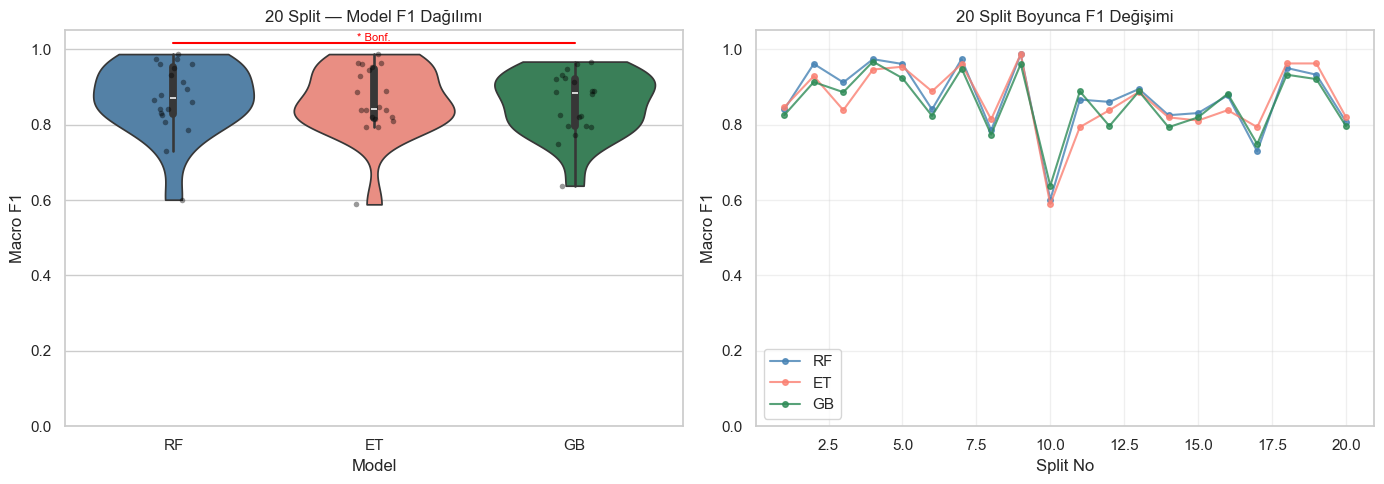

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Violin + strip plot
f1_long = f1_df.melt(var_name='Model', value_name='Macro F1')
ax = axes[0]
sns.violinplot(data=f1_long, x='Model', y='Macro F1',
               palette={'RF':'steelblue','ET':'salmon','GB':'seagreen'},
               inner='box', ax=ax, cut=0)
sns.stripplot(data=f1_long, x='Model', y='Macro F1',
              color='black', alpha=0.4, size=4, jitter=True, ax=ax)
ax.set_title('20 Split — Model F1 Dağılımı')
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.05)

# Bonferroni anlamlılık çizgisi ekle
model_order = ['RF', 'ET', 'GB']
model_pos   = {m: i for i, m in enumerate(model_order)}
y_top = f1_df.values.max() + 0.03
for row in wilcoxon_sonuclar:
    m1, m2 = row['Karşılaştırma'].split(' vs ')
    if '✓' in row['Anlamlı (α=0.05)?']:
        x1, x2 = model_pos[m1], model_pos[m2]
        ax.plot([x1, x2], [y_top, y_top], color='red', linewidth=1.5)
        ax.text((x1+x2)/2, y_top+0.005, '* Bonf.', ha='center', fontsize=8, color='red')
        y_top += 0.04

# Sağ: 20 split'te F1 seyrini gösteren çizgi grafiği
ax2 = axes[1]
for model, renk in [('RF','steelblue'), ('ET','salmon'), ('GB','seagreen')]:
    ax2.plot(range(1, N_SPLITS+1), f1_df[model], marker='o', markersize=4,
             linewidth=1.5, alpha=0.8, color=renk, label=model)
ax2.set_xlabel('Split No')
ax2.set_ylabel('Macro F1')
ax2.set_title('20 Split Boyunca F1 Değişimi')
ax2.legend()
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig_istatistiksel_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
print('=' * 60)
print('İSTATİSTİKSEL ANALİZ ÖZET')
print('=' * 60)
print(f'Test sayısı  : {N_SPLITS} split')
print(f'Modeller     : RF, ET, GB')
print(f'Friedman p   : {p_friedman:.6f} → {"Genel fark VAR" if p_friedman < 0.05 else "Genel fark YOK"}')
print()
print('Model Ortalamaları:')
for m in ['RF','ET','GB']:
    print(f'  {m}: {f1_df[m].mean():.4f} ± {f1_df[m].std():.4f}')
print()
print('Wilcoxon + Bonferroni Sonuçları:')
for row in wilcoxon_sonuclar:
    print(f'  {row["Karşılaştırma"]}: {row["Anlamlı (α=0.05)?"]}')
print('=' * 60)
print('\nSıradaki adım → 08_performans_grafikleri.ipynb')


İSTATİSTİKSEL ANALİZ ÖZET
Test sayısı  : 20 split
Modeller     : RF, ET, GB
Friedman p   : 0.020526 → Genel fark VAR

Model Ortalamaları:
  RF: 0.8705 ± 0.0956
  ET: 0.8639 ± 0.0922
  GB: 0.8563 ± 0.0839

Wilcoxon + Bonferroni Sonuçları:
  RF vs ET: ✗ Hayır
  RF vs GB: ✓ Evet
  ET vs GB: ✗ Hayır

Sıradaki adım → 08_performans_grafikleri.ipynb


---
## Bonus D — Özellik Kararlılığı (Feature Stability) Analizi

20 split boyunca MRMR'ın **hangi özellikleri ne sıklıkla seçtiğini** ölçüyoruz.  
Bir özellik her split'te seçiliyorsa kararlılık skoru = 1.0 (mükemmel).  
Bu analiz modelin hangi klinik sinyallere gerçekten güvendiğini gösterir.


In [9]:
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np, pandas as pd, time

print('Özellik kararlılığı analizi başlıyor...')
baslangic_d = time.time()

secilen_ozellikler = []   # her split'te seçilen K özelliğin listesi

for split_no in range(N_SPLITS):
    train_df, val_df, test_df = hasta_bazinda_bol(df, random_state=split_no*7+42)

    pipe = RadyomikOnIsleme()
    X_tr = pipe.fit_transform(train_df[feature_cols].values, feature_cols)
    y_tr = train_df['label'].values
    proc_cols = pipe.feats_corr

    feats = mrmr_classif(
        X=pd.DataFrame(X_tr, columns=proc_cols),
        y=pd.Series(y_tr), K=MRMR_K
    )
    secilen_ozellikler.append(feats)
    print(f'  Split {split_no+1:2d}/20 tamamlandı')

print(f'\n✓ Tüm split\'ler tamamlandı — {(time.time()-baslangic_d)/60:.1f} dk')

# Frekans sayımı
tum_secimler = [feat for split_list in secilen_ozellikler for feat in split_list]
sayim = Counter(tum_secimler)
kararlık_df = pd.DataFrame(
    [(feat, cnt, cnt/N_SPLITS) for feat, cnt in sayim.most_common()],
    columns=['Ozellik', 'Secilme_Sayisi', 'Kararlilik_Skoru']
)

print('\n=== EN KARARLI 15 ÖZELLİK ===')
display(kararlık_df.head(15).round(3))

# Stabilite istatistikleri
print(f'\nToplam eşsiz özellik (20 split): {len(sayim)}')
print(f'Tüm split\'lerde seçilen (skor=1.0): {(kararlık_df.Kararlilik_Skoru==1.0).sum()}')
print(f'>=0.8 kararlılık: {(kararlık_df.Kararlilik_Skoru>=0.8).sum()}')
print(f'>=0.5 kararlılık: {(kararlık_df.Kararlilik_Skoru>=0.5).sum()}')


Özellik kararlılığı analizi başlıyor...


100%|██████████| 10/10 [00:00<00:00, 67.22it/s]


  Split  1/20 tamamlandı


100%|██████████| 10/10 [00:00<00:00, 72.20it/s]


  Split  2/20 tamamlandı


...

  Split 19/20 tamamlandı


100%|██████████| 10/10 [00:00<00:00, 75.83it/s]

  Split 20/20 tamamlandı

✓ Tüm split'ler tamamlandı — 0.1 dk

=== EN KARARLI 15 ÖZELLİK ===


,Ozellik,Secilme_Sayisi,Kararlilik_Skoru
0,Feature_0479,20,1.00
1,Feature_0478,20,1.00
2,Feature_0003,20,1.00
3,Feature_0072,20,1.00
4,Feature_0442,20,1.00
5,Feature_0028,18,0.90
6,Feature_0061,16,0.80
7,Feature_0067,11,0.55
8,Feature_0006,7,0.35
9,Feature_0237,5,0.25



Toplam eşsiz özellik (20 split): 31
Tüm split'lerde seçilen (skor=1.0): 5
>=0.8 kararlılık: 7
>=0.5 kararlılık: 8


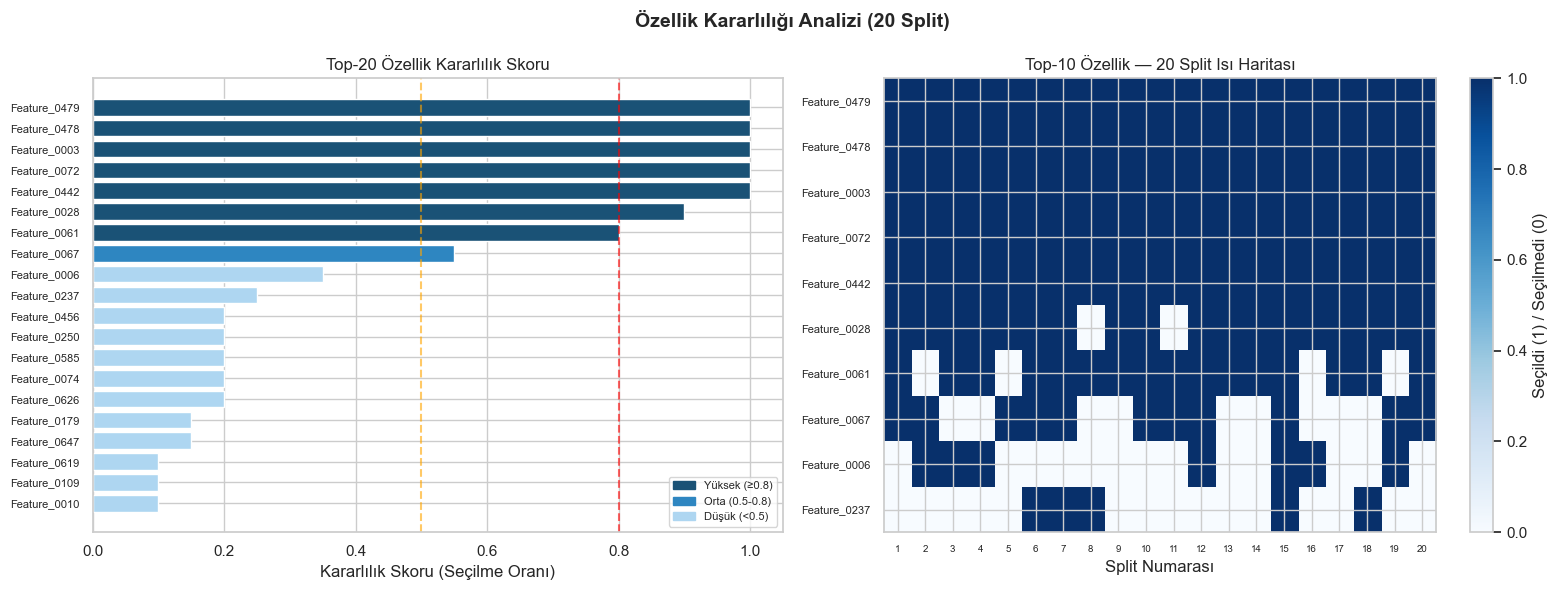

✓ fig_ozellik_kararlilik.png kaydedildi


In [10]:
# Özellik kararlılığı görselleştirme
top20 = kararlık_df.head(20).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Özellik Kararlılığı Analizi (20 Split)', fontsize=14, fontweight='bold')

# Sol: Yatay bar grafik
ax = axes[0]
colors = ['#1a5276' if s >= 0.8 else '#2e86c1' if s >= 0.5 else '#aed6f1'
          for s in top20.Kararlilik_Skoru]
bars = ax.barh(range(len(top20)), top20.Kararlilik_Skoru, color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f[:40] for f in top20.Ozellik], fontsize=8)
ax.set_xlabel('Kararlılık Skoru (Seçilme Oranı)')
ax.set_title('Top-20 Özellik Kararlılık Skoru')
ax.axvline(0.8, color='red', linestyle='--', alpha=0.6, label='Eşik: 0.8')
ax.axvline(0.5, color='orange', linestyle='--', alpha=0.6, label='Eşik: 0.5')
ax.set_xlim(0, 1.05)
legend_patches = [
    mpatches.Patch(color='#1a5276', label='Yüksek (≥0.8)'),
    mpatches.Patch(color='#2e86c1', label='Orta (0.5-0.8)'),
    mpatches.Patch(color='#aed6f1', label='Düşük (<0.5)'),
]
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')
ax.invert_yaxis()

# Sağ: Isı haritası — her split için hangi özellikler seçildi
ax2 = axes[1]
top10_feats = kararlık_df.head(10).Ozellik.tolist()
heatmap_data = np.zeros((10, N_SPLITS))
for j, split_feats in enumerate(secilen_ozellikler):
    for i, feat in enumerate(top10_feats):
        if feat in split_feats:
            heatmap_data[i, j] = 1

im = ax2.imshow(heatmap_data, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(N_SPLITS))
ax2.set_xticklabels([str(i+1) for i in range(N_SPLITS)], fontsize=7)
ax2.set_yticks(range(10))
ax2.set_yticklabels([f[:35] for f in top10_feats], fontsize=8)
ax2.set_xlabel('Split Numarası')
ax2.set_title('Top-10 Özellik — 20 Split Isı Haritası')
plt.colorbar(im, ax=ax2, label='Seçildi (1) / Seçilmedi (0)')

plt.tight_layout()
plt.savefig('../figures/fig_ozellik_kararlilik.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig_ozellik_kararlilik.png kaydedildi')


---
## Bonus E — Threshold Optimizasyonu (Youden J İstatistiği)

Varsayılan karar eşiği 0.5 her zaman optimum değildir.  
**Youden J = Sensitivity + Specificity − 1** formülünü maksimize eden eşik bulunur.  
Klinik açıdan önemlidir: papilödemayı kaçırmak (FN) vs yanlış alarm (FP) dengelemesi.


In [11]:
from sklearn.metrics import roc_curve, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV

print('Threshold optimizasyonu hesaplanıyor...')
baslangic_e = time.time()

threshold_sonuclari = []

for split_no in range(N_SPLITS):
    train_df, val_df, test_df = hasta_bazinda_bol(df, random_state=split_no*7+42)

    pipe = RadyomikOnIsleme()
    X_tr = pipe.fit_transform(train_df[feature_cols].values, feature_cols)
    X_te = pipe.transform(test_df[feature_cols].values, feature_cols)
    y_tr = train_df['label'].values
    y_te = test_df['label'].values
    groups = train_df['PatientIndex'].values
    proc_cols = pipe.feats_corr

    feats = mrmr_classif(
        X=pd.DataFrame(X_tr, columns=proc_cols),
        y=pd.Series(y_tr), K=MRMR_K
    )
    X_tr_m = pd.DataFrame(X_tr, columns=proc_cols)[feats].values
    X_te_m = pd.DataFrame(X_te, columns=proc_cols)[feats].values

    params = {m: optuna_en_iyi_params(X_tr_m, y_tr, groups, m) for m in ['RF','ET','GB']}

    estimators = [
        ('RF', RandomForestClassifier(**params['RF'], random_state=42, n_jobs=-1)),
        ('ET', ExtraTreesClassifier(**params['ET'], random_state=42, n_jobs=-1)),
        ('GB', GradientBoostingClassifier(**params['GB'], random_state=42)),
    ]
    ensemble = VotingClassifier(estimators=estimators, voting='soft')
    cal = CalibratedClassifierCV(ensemble, cv=3)
    cal.fit(X_tr_m, y_tr)
    y_prob = cal.predict_proba(X_te_m)[:, 1]

    # Youden J: ROC eğrisi üzerinden
    fpr, tpr, thresholds = roc_curve(y_te, y_prob)
    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    optimal_thresh = thresholds[optimal_idx]

    # Default (0.5) vs optimal threshold metrikleri
    for thr_label, thr in [('default_0.5', 0.5), ('optimal_youden', optimal_thresh)]:
        y_pred_thr = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_te, y_pred_thr, labels=[0,1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        threshold_sonuclari.append({
            'split': split_no,
            'threshold_tipi': thr_label,
            'threshold': thr,
            'sensitivity': sens,
            'specificity': spec,
            'f1_macro': f1_score(y_te, y_pred_thr, average='macro', zero_division=0),
            'youden_j': sens + spec - 1
        })

    if (split_no+1) % 5 == 0:
        print(f'  Split {split_no+1}/20 — Optimal eşik: {optimal_thresh:.3f}')

print(f'\n✓ Tamamlandı — {(time.time()-baslangic_e)/60:.1f} dk')

thr_df = pd.DataFrame(threshold_sonuclari)
ozet = thr_df.groupby('threshold_tipi')[['threshold','sensitivity','specificity','f1_macro','youden_j']].mean()
print('\n=== THRESHOLD KARŞILAŞTIRMA ÖZET ===')
display(ozet.round(4))


Threshold optimizasyonu hesaplanıyor...


100%|██████████| 10/10 [00:00<00:00, 72.46it/s]


  Split 5/20 — Optimal eşik: 0.456


100%|██████████| 10/10 [00:00<00:00, 73.81it/s]


  Split 10/20 — Optimal eşik: 0.037


100%|██████████| 10/10 [00:00<00:00, 74.17it/s]


  Split 15/20 — Optimal eşik: 0.695


100%|██████████| 10/10 [00:00<00:00, 70.61it/s]


  Split 20/20 — Optimal eşik: 0.145

✓ Tamamlandı — 21.2 dk

=== THRESHOLD KARŞILAŞTIRMA ÖZET ===


,threshold,sensitivity,specificity,f1_macro,youden_j
threshold_tipi,,,,,
default_0.5,0.5000,0.7455,0.9595,0.8629,0.7051
optimal_youden,0.3849,0.8580,0.9183,0.8851,0.7763


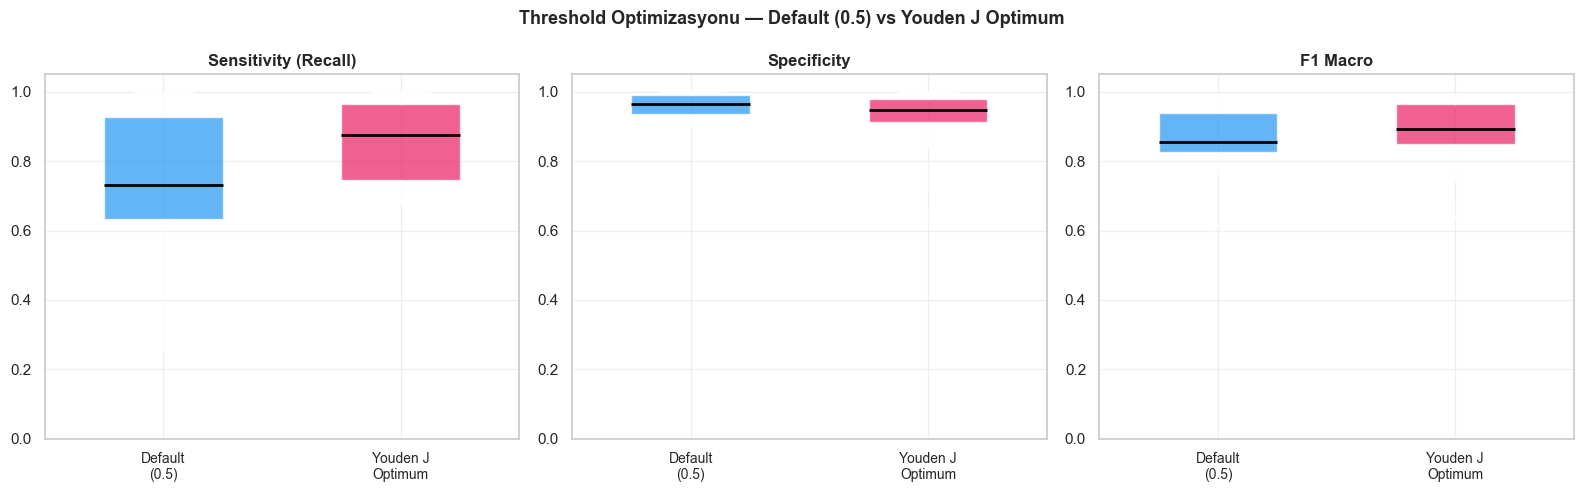

✓ fig_threshold_optimizasyon.png kaydedildi
Ortalama optimal threshold: 0.385
Not: 0.5 yerine bu eşik kullanıldığında sensitivity artış beklenir.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Threshold Optimizasyonu — Default (0.5) vs Youden J Optimum', fontsize=13, fontweight='bold')

metriks = ['sensitivity', 'specificity', 'f1_macro']
basliklar = ['Sensitivity (Recall)', 'Specificity', 'F1 Macro']
renkler = {'default_0.5': '#2196F3', 'optimal_youden': '#E91E63'}

for ax, met, bas in zip(axes, metriks, basliklar):
    for tip, renk in renkler.items():
        deger = thr_df[thr_df.threshold_tipi==tip][met]
        ax.boxplot(deger, positions=[list(renkler.keys()).index(tip)],
                   widths=0.5, patch_artist=True,
                   boxprops=dict(facecolor=renk, alpha=0.7),
                   medianprops=dict(color='black', linewidth=2))
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Default\n(0.5)', 'Youden J\nOptimum'], fontsize=10)
    ax.set_title(bas, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig_threshold_optimizasyon.png', dpi=150, bbox_inches='tight')
plt.show()

optimal_ort = thr_df[thr_df.threshold_tipi=='optimal_youden']['threshold'].mean()
print(f'✓ fig_threshold_optimizasyon.png kaydedildi')
print(f'Ortalama optimal threshold: {optimal_ort:.3f}')
print(f'Not: 0.5 yerine bu eşik kullanıldığında sensitivity artış beklenir.')
